This notebook shows how to use annotation_morphing.py functions to prepare annotations for un-annotated sections

In [34]:
import sys
sys.path.append('..')
from dharani_functions import DharaniHelper
from matplotlib import pyplot as plt

In [35]:
import logging

logging.basicConfig(level=logging.WARNING, force=True)

In [36]:
helper = DharaniHelper(specimennum=2,downsample=7)

In [37]:
secnos = helper.get_section_numbers()

In [38]:
from csv_handling import load_csv
import os

listing = {}
listingcsvname = f'../directory-listings/Dharani_Specimen_{helper._specimennum}.csv'
if os.path.exists(listingcsvname):
    listing = load_csv(listingcsvname)


Find the annotated section numbers, by checking row.atlas_url

In [39]:
annotated_secnos = []
for secnum, row in listing.items():
    if row.atlas_url != '':
        annotated_secnos.append(int(row.section_number))
    

Find gaps. Let x be the sorted list of section numbers, and Dx be the first finite difference 
```Dx[i] = (x[i+1]-x[i])```

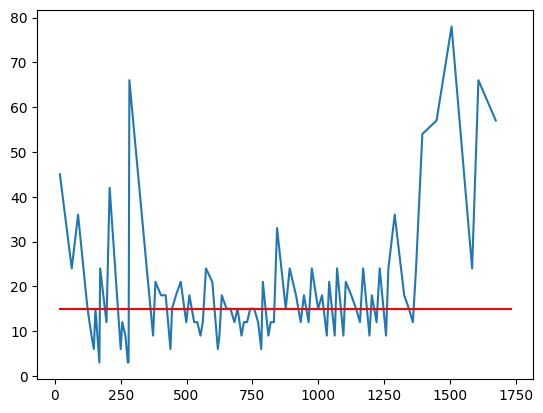

In [40]:
import numpy as np
from matplotlib import pyplot as plt
x = np.array(sorted(annotated_secnos))
Dx = np.diff(x)
plt.plot(x[:-1],Dx)
plt.plot(x,[np.median(Dx)]*len(x),'r-')

Find the median of Dx

In [41]:
np.median(Dx), np.std(Dx)

(15.0, 14.283864471648196)

**Note**: in Dharani, the section number separation between consecutive Nissl sections is 3 (i.e., 3x20um slice thickness =60 um separation). A median value of 15 indicates 1 in 5 sections are annotated (or roughly one per 300 um)

In [42]:
pos = np.where(Dx>15)
pos,x[pos],Dx[pos]

((array([ 0,  1,  2,  8, 10, 16, 17, 19, 20, 21, 24, 25, 27, 32, 33, 36, 48,
         52, 54, 55, 57, 59, 61, 63, 65, 67, 68, 71, 73, 75, 77, 78, 79, 82,
         83, 84, 85, 86, 87, 88], dtype=int64),),
 array([  19,   64,   88,  172,  208,  283,  349,  382,  403,  421,  460,
         478,  511,  574,  598,  634,  790,  844,  892,  916,  946,  976,
        1015, 1042, 1072, 1105, 1126, 1171, 1204, 1234, 1267, 1291, 1327,
        1372, 1396, 1450, 1507, 1585, 1609, 1675]),
 array([45, 24, 36, 24, 42, 66, 24, 21, 18, 18, 18, 21, 18, 24, 21, 18, 21,
        33, 24, 18, 18, 24, 18, 21, 24, 21, 18, 24, 18, 24, 24, 36, 18, 24,
        54, 57, 78, 24, 66, 57]))

Select a gap

In [43]:
x[16:18]

array([283, 349])

In [44]:
annot283 = helper.get_annotation(283)
annot349 = helper.get_annotation(349)

In [45]:
from nb_functions import display_shape

In [46]:
im283 = helper.get_sectionimage(283)
im349 = helper.get_sectionimage(349)

In [47]:
annot283.keys()

dict_keys([13, 16, 15, 14, 500, 131, 243, 226, 53, 52, 51, 50, 54, 49, 48, 229, 505, 34, 40, 41, 42, 43, 31, 503, 504, 502, 501, 236, 244, 158, 506, 35, 44, 36, 45, 32, 33])

In [48]:
annot349.keys()

dict_keys([36, 229, 45, 44, 226, 43, 42, 41, 40, 31, 34, 35, 33, 32, 48, 50, 51, 52, 53, 54, 49, 143, 236, 142, 505, 506, 158, 17, 13, 503, 131, 156, 504, 501, 244, 1026, 243, 502, 500, 134, 14, 15, 16])

In [49]:
# find the left-outer, intersection, right-outer using set operations

common_keys = set(annot283.keys()).intersection(set(annot349.keys()))

In [50]:
left_keys = set(annot283.keys())-set(annot349.keys())

In [51]:
right_keys = set(annot349.keys())-set(annot283.keys())

In [52]:
left_keys

set()

In [53]:
common_keys

{13,
 14,
 15,
 16,
 31,
 32,
 33,
 34,
 35,
 36,
 40,
 41,
 42,
 43,
 44,
 45,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 131,
 158,
 226,
 229,
 236,
 243,
 244,
 500,
 501,
 502,
 503,
 504,
 505,
 506}

In [54]:
right_keys

{17, 134, 142, 143, 156, 1026}

**Note**: this means that all annotations in section 283 (left) are seen in section 349 (right) (no region disappeared), but some regions are newly seen in section 349

In [55]:
from annotation_handling import get_properties

In [56]:
props = {}
for key in common_keys:
    props[key] = ( get_properties(annot283[key]), get_properties(annot349[key]) )
    

List the area before and after, of the common structures

In [57]:
{k:(props[k][0]['area'], props[k][1]['area']) for k in sorted(common_keys, key=lambda x:props[x][0]['area'])}

{506: (32.210876725705454, 46.6608394557311),
 13: (32.478472205994585, 34.72393059626219),
 36: (53.29329981976279, 144.4696201652123),
 243: (59.278646473060824, 85.77689272321486),
 229: (64.75578865932857, 1757.0545172852885),
 45: (71.17193205677253, 69.08219855970549),
 131: (82.57907914837956, 246.90590102211334),
 40: (85.2044712941386, 90.61732618583768),
 44: (107.18763400143688, 187.4199312580076),
 31: (112.27421850432884, 194.32031040343495),
 48: (118.49426333697873, 78.37326288469129),
 54: (126.19119206253042, 96.12992384654183),
 244: (135.53639171655192, 31.051301820900406),
 500: (139.11051093778883, 43.936554500798586),
 35: (252.7010982377306, 340.5646822303152),
 49: (275.8866185521255, 214.84287701648788),
 236: (283.31999893300514, 381.7962242263305),
 505: (299.17597877625815, 221.66369284246431),
 53: (442.28665666882506, 549.4376262744978),
 14: (463.9419173003403, 473.12147047041105),
 41: (597.5030811880283, 720.3985865928846),
 501: (841.9839718684774, 120

Select a key from one of the above, to see a comparative visual

In [58]:
ontoid = 158

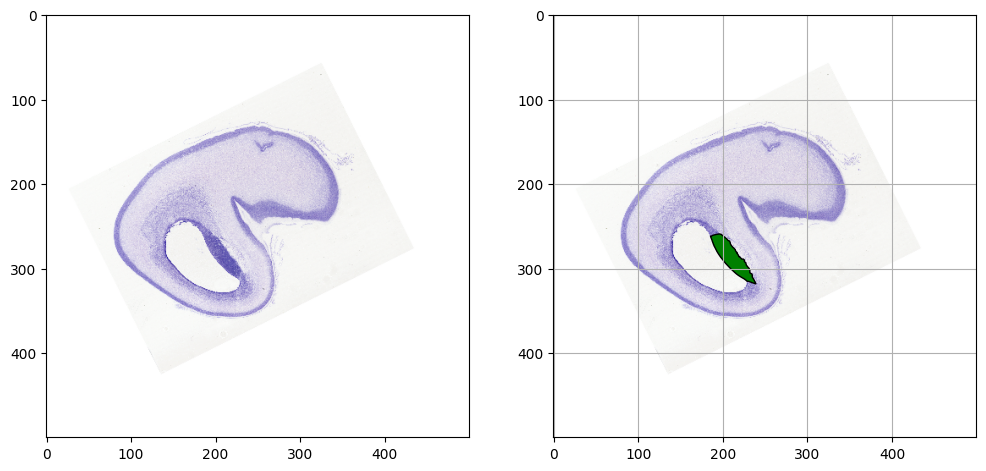

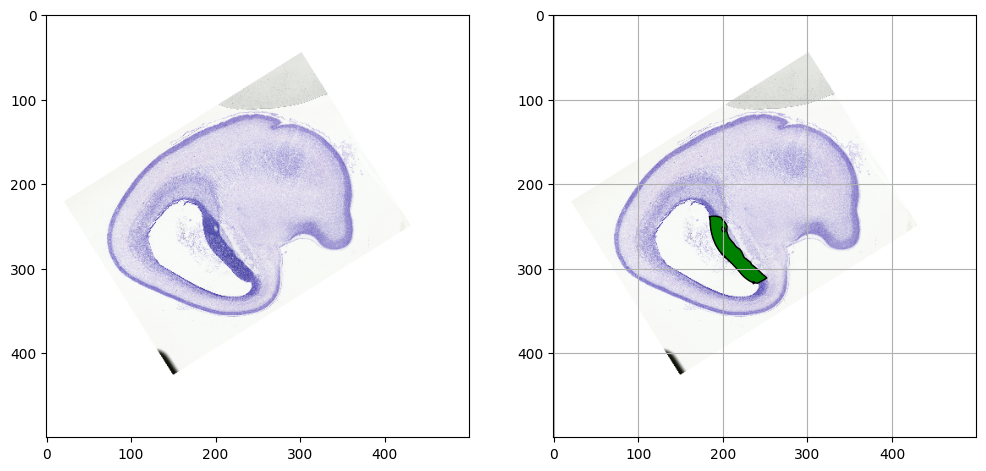

In [59]:
display_shape(im283, annot283[ontoid], 'g')
plt.show()
display_shape(im349, annot349[ontoid],'g')

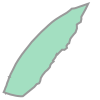

In [60]:
annot283[ontoid]

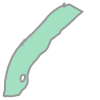

In [61]:
annot349[ontoid]

In [62]:
from nb_functions import plot_shape

Overlay the two in a plot

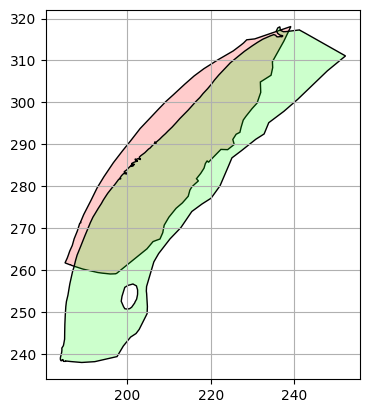

In [63]:
plot_shape(annot283[ontoid],(1,0,0,0.2))
plot_shape(annot349[ontoid],(0,1,0,0.2))

The morph call

In [64]:
from annotation_morphing import morph_shape

In [65]:
mpp=2**helper._downsample

286


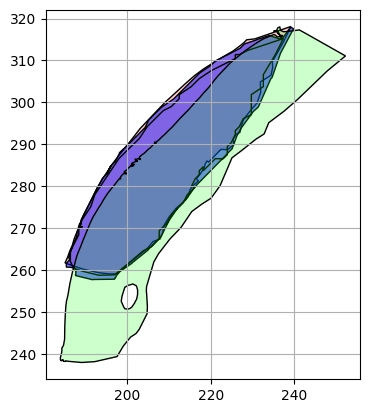

289


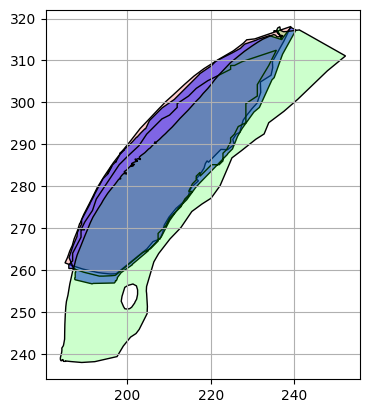

292


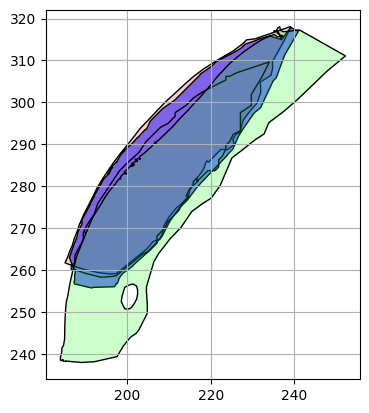

295


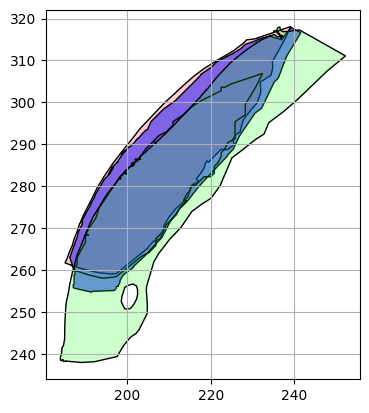

298


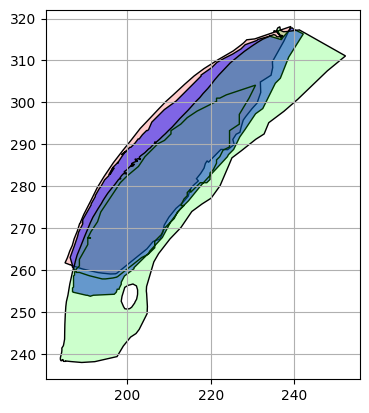

301


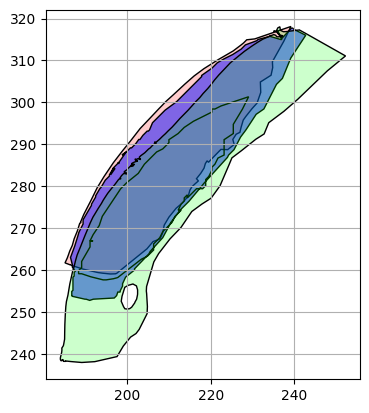

304


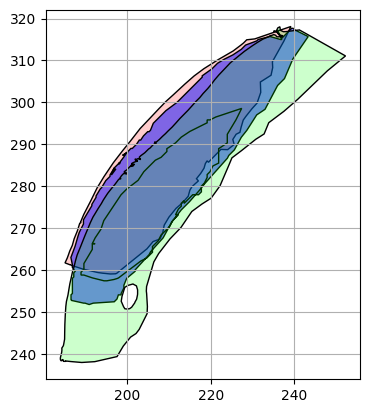

307


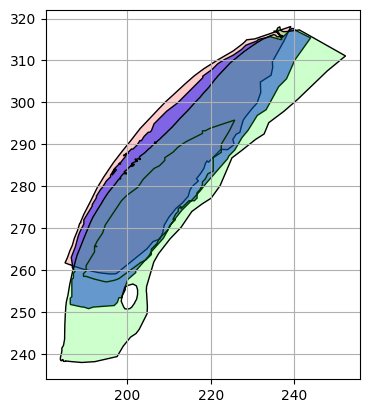

310


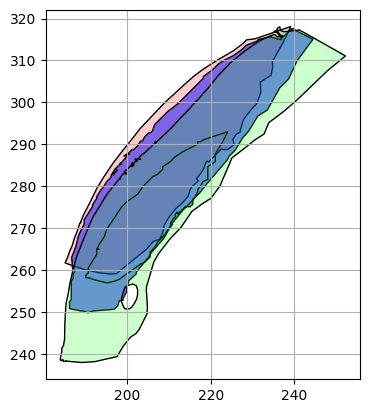

313


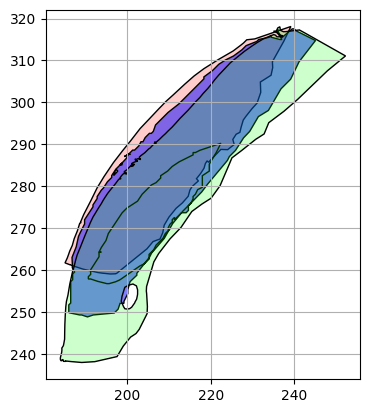

316


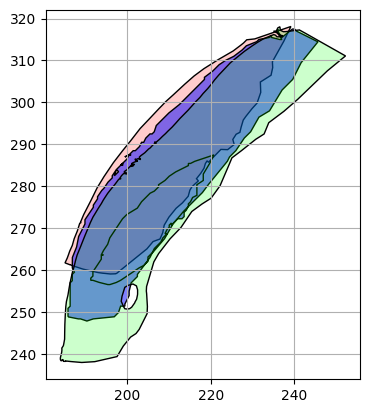

319


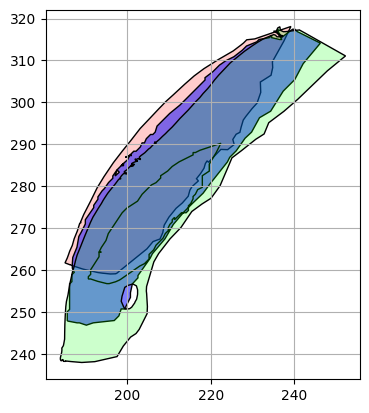

322


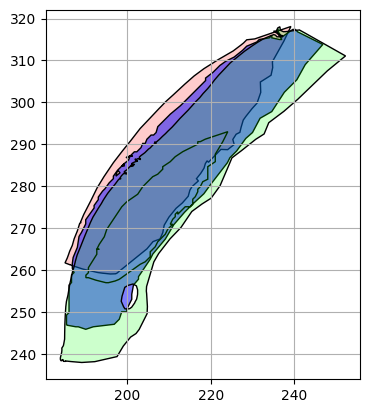

325


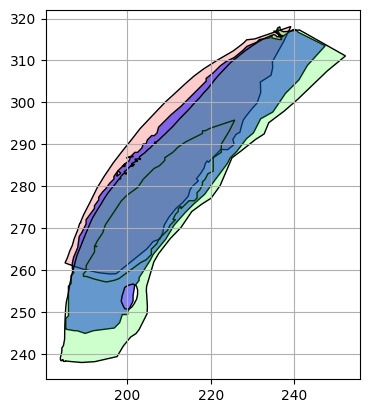

328


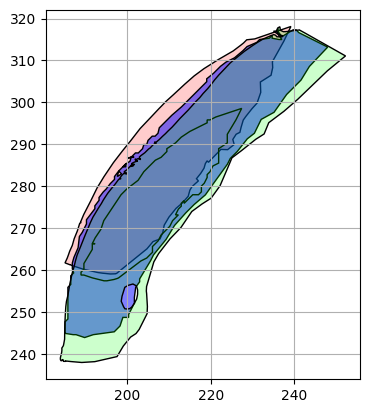

331


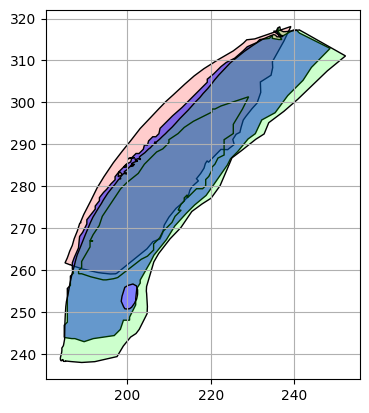

334


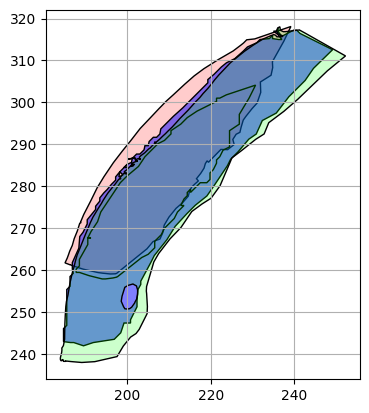

337


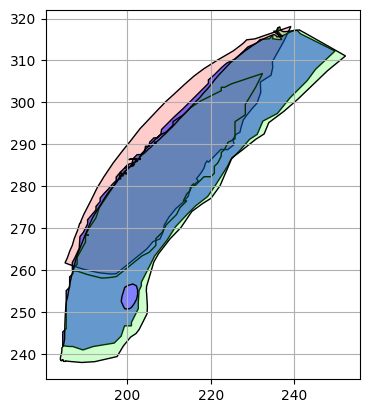

340


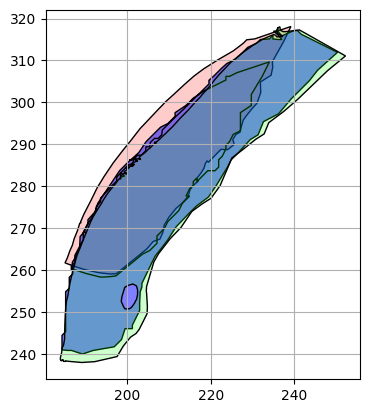

343


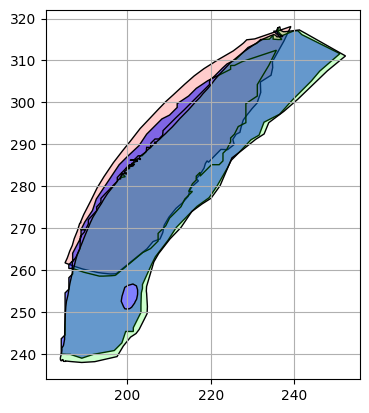

346


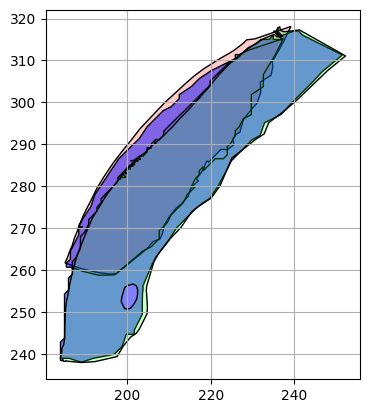

In [66]:
tweened={}
from_sec = 283
to_sec = 349
for secno in range(from_sec+3, to_sec, 3):
    tweened[secno] = morph_shape(annot283[ontoid], annot349[ontoid], from_sec, to_sec, secno, mpp)
    print(secno)
    plot_shape(annot283[ontoid],(1,0,0,0.2))
    plot_shape(tweened[secno],(0,0,1,0.5))
    plot_shape(annot349[ontoid],(0,1,0,0.2))
    plt.show()
    # break